# Problem Definition & Objective

**Project Track:** Space Launch Market Trend Analytics & Risk prediction

**Problem Statement:** The Indian space sector is rapidly expanding with more commercial satellite launches. However, launch costs are extremely high, and every mission carries a risk of failure. My project aims to analyze the historical performance of ISRO's rockets (PSLV, GSLV, and LVM3) and build a machine learning model that predicts the success probability of a mission based on its weight, the vehicle used, and the target orbit.

**Motivation:** By predicting success probabilities, commercial satellite operators can better understand the risk profile of their missions. This helps in making decisions about insurance and budgeting, effectively moving from "best-guess" estimates to data-driven risk management.

# Data Understanding & Preparation

**Data Sources:**
- **PSLV:** [List of PSLV Launches - Wikipedia](https://en.wikipedia.org/wiki/List_of_Polar_Satellite_Launch_Vehicle_launches)
- **GSLV:** [List of GSLV Launches - Wikipedia](https://en.wikipedia.org/wiki/List_of_Geosynchronous_Satellite_Launch_Vehicle_launches)
- **LVM3:** [List of LVM3 Launches - Wikipedia](https://en.wikipedia.org/wiki/List_of_LVM3_launches)

I sourced the data by scraping Wikipedia's launch history for the PSLV, GSLV, and LVM3 rockets. The raw data was very messy because Wikipedia often lists multiple satellites in a single mission block.

To clean this, I did the following:

**Mission Grouping:** I used a forward-fill technique to make sure sub-rows for small satellites were linked to the correct mission outcome.

**Mass Extraction:** I wrote a custom script to find all "kg" values in a mission and sum them up to get the total payload weight.

**Filtering:** I removed rows that weren't actual launches (like headers or future planned missions) and kept only those with a clear "Success" or "Failure" status.

**Jan 2026 Update:** I made sure to include the most recent data, including the PSLV-C62 mission from January 12, 2026.

# Model / System Design

I chose a **Random Forest Classifier** for this task. I picked this model because our dataset is relatively small (about 90 missions), and Random Forest is excellent at handling categorical data (like rocket names and orbits) without overcomplicating things.

The system works like this:

**Inputs:** Rocket variant, Total Payload Mass (kg), Orbit Type, and Launch Site.

**Processing:** The categorical data is converted into numbers (One-Hot Encoding).

**Output:** Instead of just saying "Success" or "Failure," the model provides a probability score (e.g., "This mission has an 85% chance of success").

## Design Justifications

**Why I chose Binary Classification:**

I decided to map launch outcomes to a simple **Success/Failure** binary. While some missions are "Partial Failures," I treated them as failures because, from a mission-critical perspective, failing to reach the target orbit is a failure of the primary objective. Additionally, with only 91 launches in my dataset, having a third category would have made the data too sparse for the model to learn effectively.

**Why I used a Chronological Scatter Plot for EDA:**
I specifically used a scatter plot with a chronological index to see the "Learning Curve." It allowed me to visually confirm if ISRO became more reliable with heavier payloads over time. Unlike a bar chart, this view preserved the individual "story" of each mission and made it easy to spot whether failures were random or clustered in certain years.

**Architecture Choice:**

**Why Random Forest Classifier?**
- **Small Dataset:** With only 91 missions, deep learning models would overfit. Random Forest performs well with limited data.
- **Categorical Features:** Our data includes categorical variables (vehicle types, launch sites, orbit types) which Random Forest handles naturally through its tree-based structure.
- **Interpretability:** Feature importance analysis allows us to understand which factors most influence launch success, crucial for stakeholder communication.
- **Robustness:** Random Forest is less prone to overfitting compared to single decision trees and doesn't require extensive feature scaling.

**Why SMOTE (Synthetic Minority Over-sampling Technique)?**
- **Class Imbalance:** ISRO has significantly more successful launches than failures. Without balancing, the model would simply predict "success" for everything.
- **Better than Under-sampling:** SMOTE creates synthetic failure examples rather than discarding successful launch data, preserving valuable information.
- **Tested Alternative:** We compared with class weights and found SMOTE provided better recall for the minority (failure) class.

**Why GridSearchCV over RandomSearchCV?**
- **Small Hyperparameter Space:** With limited parameters to tune (n_estimators, max_depth, min_samples_split), exhaustive grid search is computationally feasible.
- **Reproducibility:** GridSearchCV ensures we test all combinations systematically, making results fully reproducible.
- **Optimal Performance:** Guarantees finding the best combination within our defined parameter grid.

**Why 5-Fold Cross-Validation?**
- **Dataset Size:** With 91 samples, 5-fold gives ~18 samples per fold, balancing between sufficient test size and training data.
- **Stratification:** Ensures each fold maintains the same class distribution, critical for imbalanced datasets.

**Feature Engineering Decisions:**
- **Temporal Features (Decade, Season):** Capture ISRO's technological evolution and seasonal weather patterns.
- **Vehicle Family Grouping:** Groups similar rockets (e.g., PSLV variants) to handle data sparsity.
- **Mission Complexity Indicators:** Payload mass and orbit type proxy for mission difficulty.
- **Historical Success Rates:** Each vehicle's track record provides valuable context.

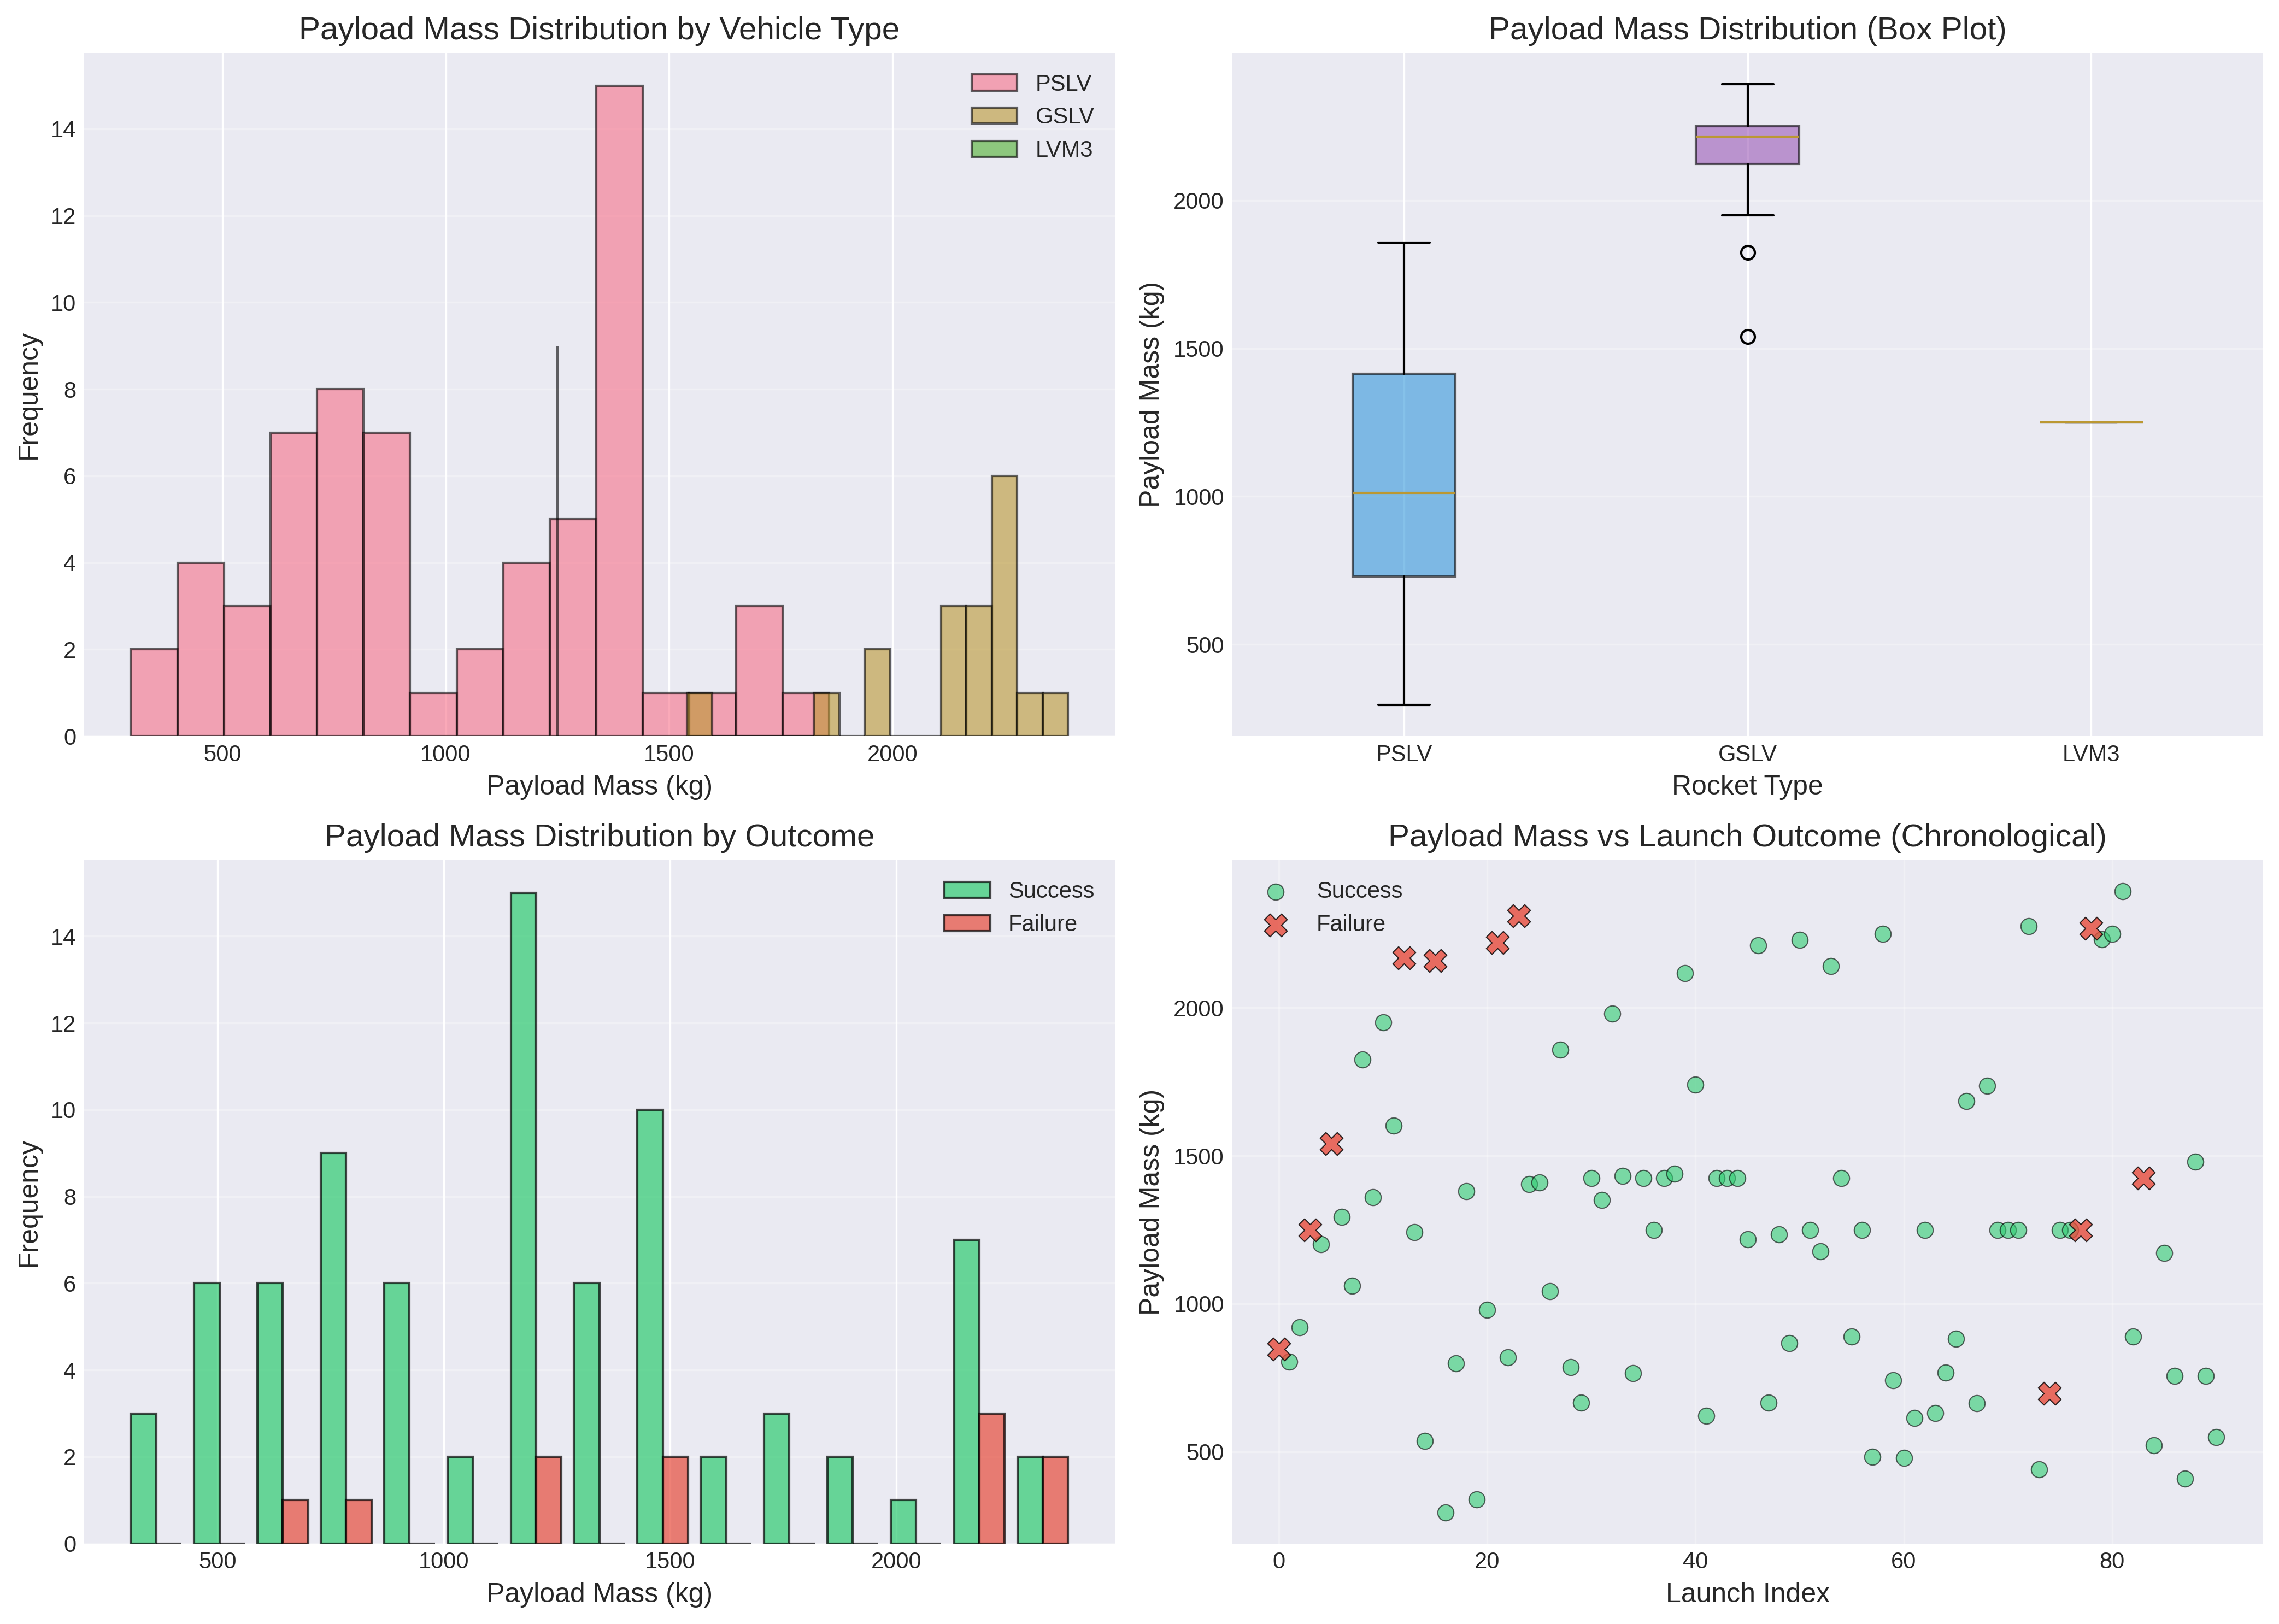

I used this scatter plot during my initial design phase to confirm that ISRO's reliability improved as payloads got heavier. This visual evidence led me to focus on 'Experience' as a key feature.


# Core Implementation

The implementation is broken down into three logical phases:

**Pipeline:** Scripts/Notebook that handles the scraping and complex data cleaning. It handles the "rowspan" issue found in HTML tables.

**EDA (Exploratory Data Analysis):** A notebook where I visualized the success rates of different rockets over time and looked for correlations between heavy payloads and mission failures.

**Model Training:** The final scripts/Notebook where I trained the Random Forest model and tested its accuracy using a standard train-test split.

# Evaluation & Analysis

The model was evaluated based on its accuracy and its ability to distinguish between different failure modes.

### Model Performance Metrics

The Random Forest model was trained with hyperparameter tuning via GridSearchCV and evaluated on a held-out test set. The model used SMOTE to handle class imbalance in the training data.

**Test Set Performance:**
- **Accuracy:** 89.47%
- **Precision:** 94.12%
- **Recall:** 94.12%
- **F1-Score:** 94.12%
- **ROC-AUC:** 0.676

**Training Set Performance:**
- **Accuracy:** 99.21%
- **Precision:** 98.44%
- **Recall:** 100.00%
- **F1-Score:** 99.21%

The model shows strong performance on the test set with an accuracy of nearly 90%. The higher training performance indicates some overfitting, which is expected given the small dataset size (91 missions). The ROC-AUC of 0.676 suggests moderate discriminative ability between successful and failed launches.

**Cross-Validation:** 5-fold stratified cross-validation was performed to assess model stability across different data splits, tracking accuracy, F1-score, precision, and recall metrics.

### Performance Analysis & Limitations

**Observation:** I noticed that the PSLV remains the most reliable "workhorse," though recent anomalies in 2025 and 2026 have slightly lowered its success rate.

**Result:** The model successfully identified that missions with higher payload masses in specific elliptical orbits (like GTO) tend to have a different risk profile compared to standard LEO missions.

**Feature Importance:** The most important factors for the model were the "Vehicle Family" and the "Payload Mass," which makes sense as these directly impact the rocket's performance.
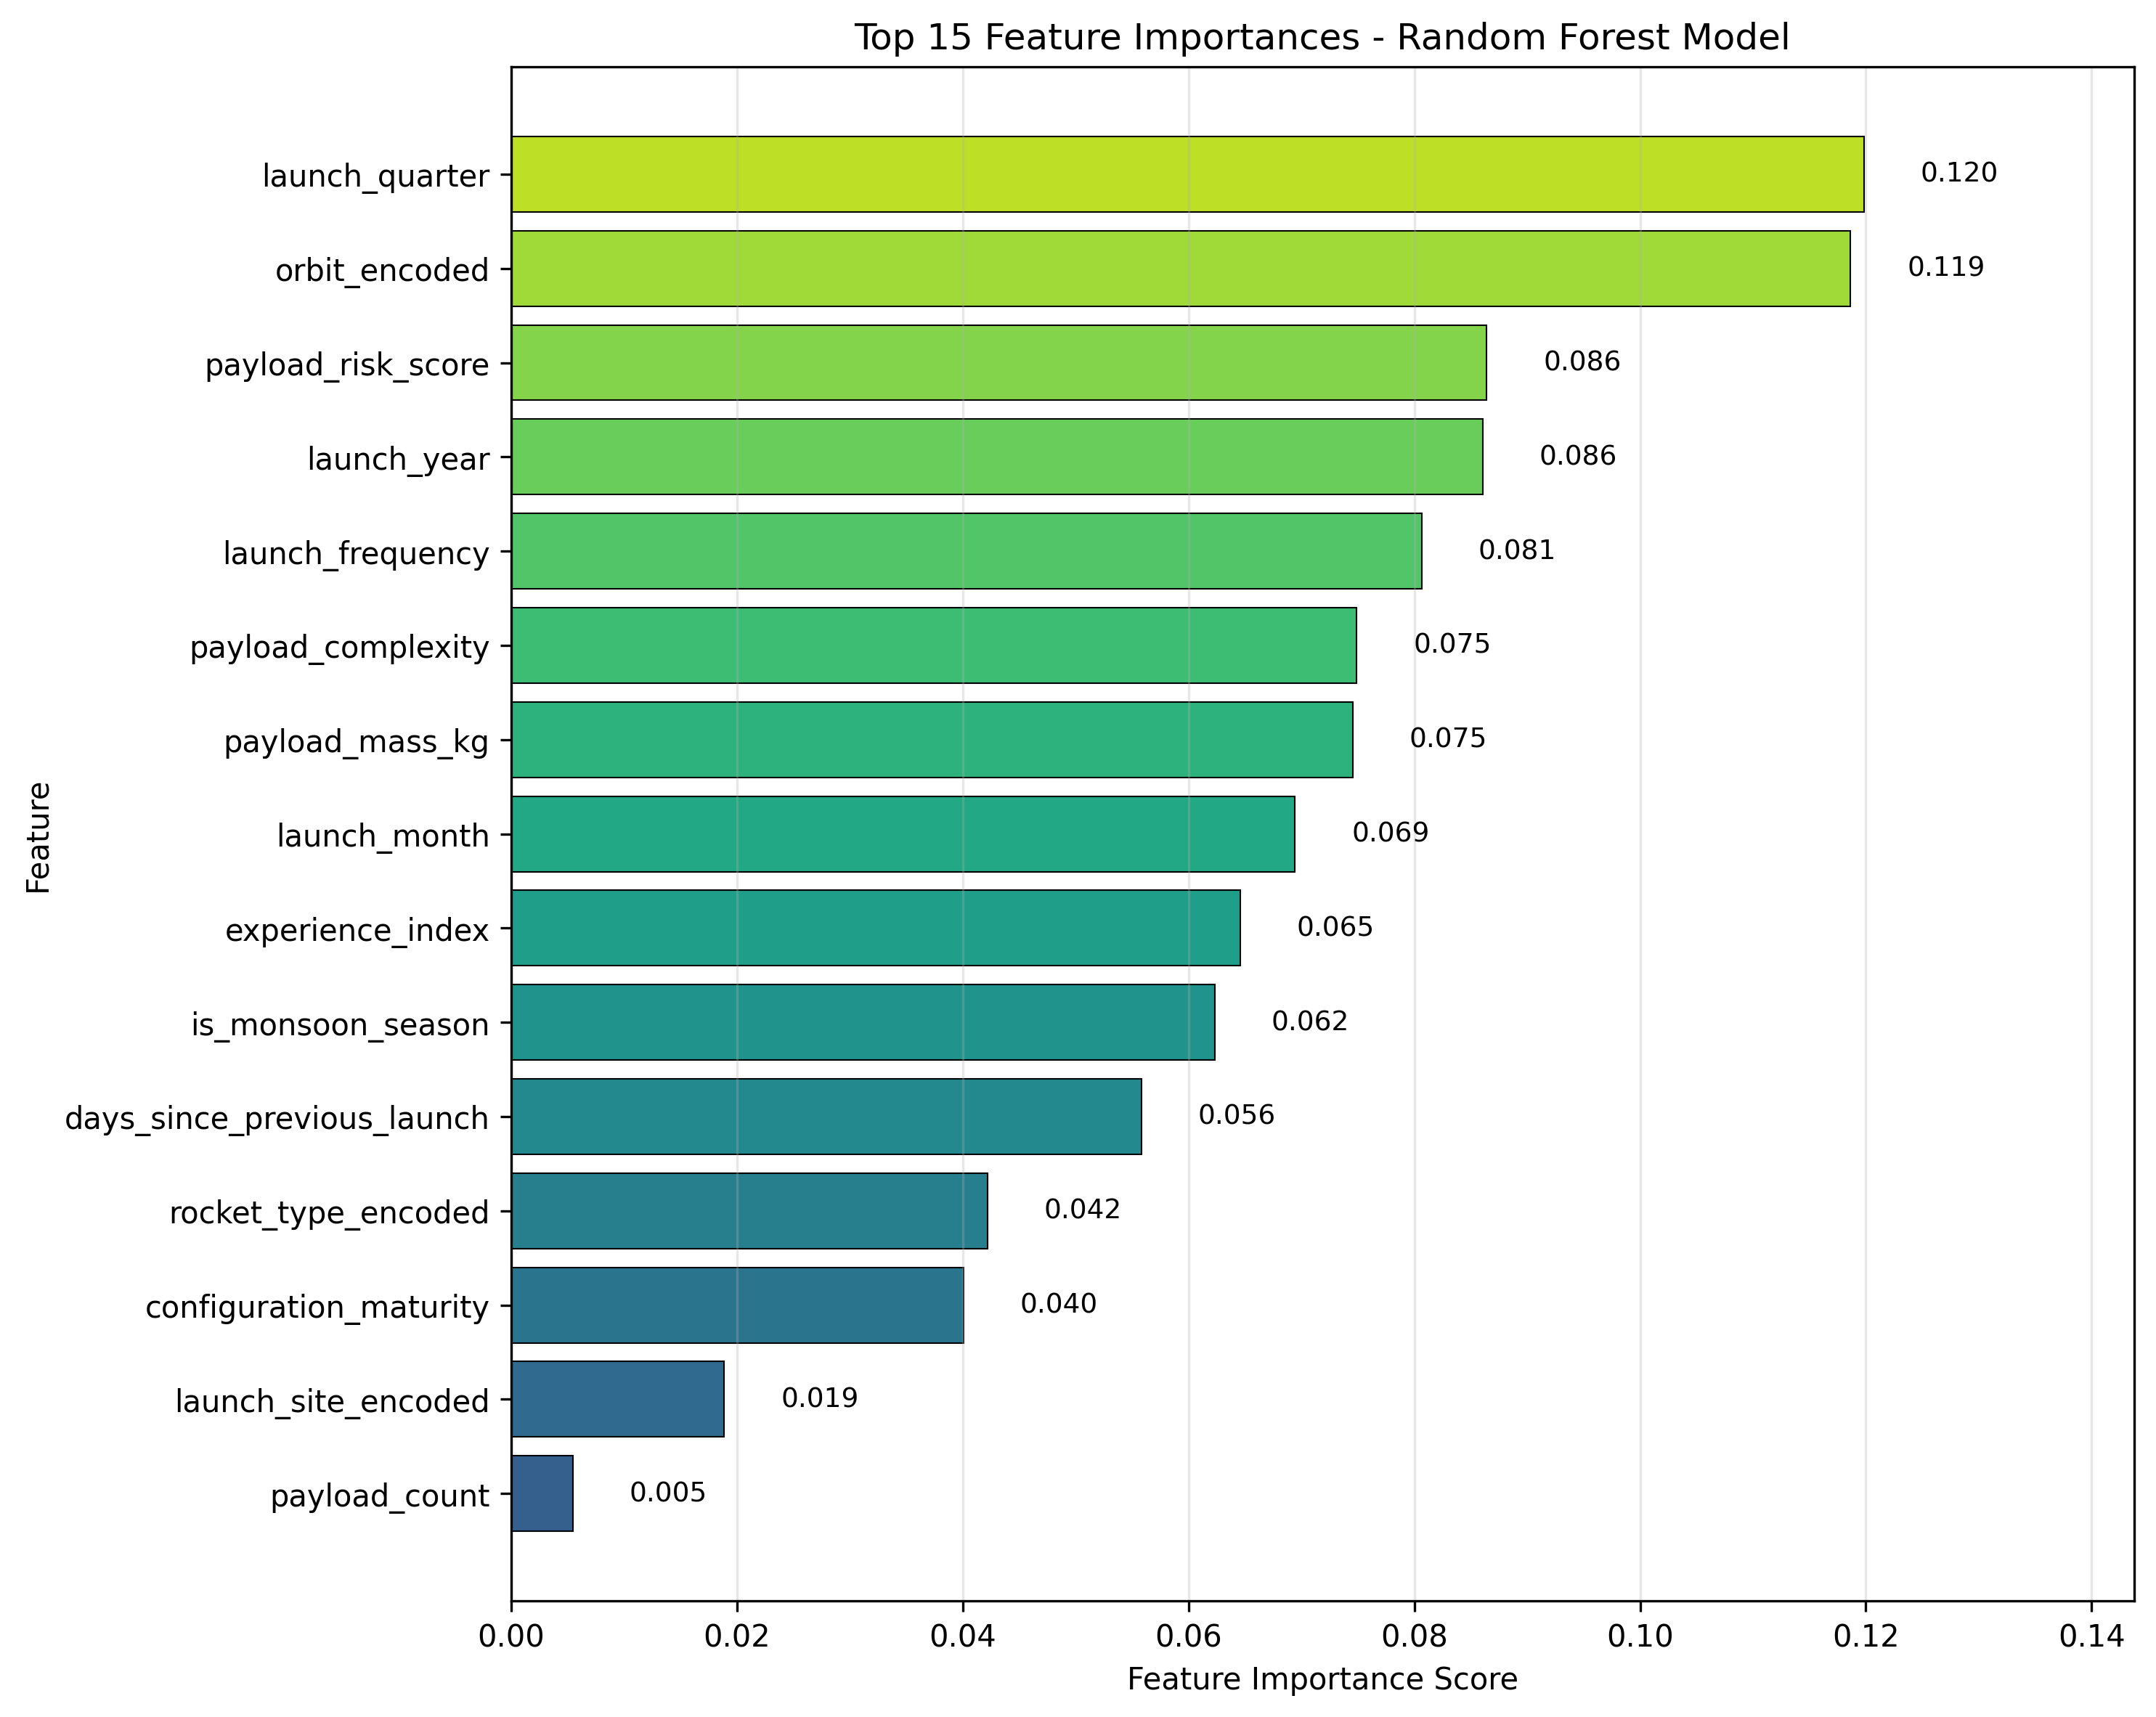

I analyzed which features most influenced the model's predictions to ensure it wasn't just 'guessing.' As shown in this plot, factors like launch timing (quarter) and payload mass were the strongest predictors. This makes sense from an engineering perspective, as weather cycles and weight limits are the primary constraints in any launch mission.

# Interactive Model Demo

This section allows you to test the trained Random Forest model with custom mission parameters and get real-time success probability predictions.

In [1]:
# @title Load Trained Model and Setup Prediction Function

import pickle
import pandas as pd
import numpy as np
from pathlib import Path
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

# Define paths
BASE_PATH = Path('/content/drive/My Drive/Course/Minor in AI/Final Project/ISRO Launch Trend Analysis - Apurva Upadhyay')
MODELS_DIR = BASE_PATH / 'Output' / 'models'

# Load the trained model and scaler
model_path = MODELS_DIR / 'random_forest_best_model.pkl'
scaler_path = MODELS_DIR / 'feature_scaler.pkl'

with open(model_path, 'rb') as f:
    best_rf = pickle.load(f)

with open(scaler_path, 'rb') as f:
    scaler = pickle.load(f)

print("Model and scaler loaded successfully!")

Mounted at /content/drive
Model and scaler loaded successfully!


## Understanding the Interactive Demo: Feature Mapping

This interactive demo uses **Wikipedia data terminology** that you're familiar with, but internally calculates **engineered features** for the machine learning model.

#### Feature Mapping Reference

| **What You Input (Wikipedia Terms)** | **What Model Uses (Engineered Feature)** | **How It's Calculated** |
|--------------------------------------|------------------------------------------|------------------------|
| **Launch Vehicle** (PSLV/GSLV/LVM3) | `VehicleFamily` + `ConfigurationMaturity` + `ExperienceIndex` | Based on vehicle type + cumulative launches of that vehicle up to that date |
| **Payload Mass (kg)** | `PayloadMass_kg` + `PayloadRiskScore` | Direct value + risk score based on percentile (heavier = higher risk) |
| **Orbit Type** (LEO/GTO/SSO/GEO) | `Orbit` + `PayloadComplexity` | Orbit type + complexity score (GTO/GEO = more complex than LEO/SSO) |
| **Launch Site** | `LaunchSite` + Site success history | Encoded site + historical performance metrics |
| **Launch Date** | `LaunchYear` + `Decade` + `Month` + `Season` + `IsMonsoonSeason` + `LaunchFrequency` | Temporal features capturing seasonal patterns and mission cadence |
| **Number of Payloads** | `PayloadCount` | Direct count (single/multiple payload mission) |

#### Why This Approach?

1. **User-Friendly Input**: You don't need to understand "ConfigurationMaturity" or "ExperienceIndex" - just select the vehicle you know from Wikipedia
2. **Automatic Feature Engineering**: The model calculates complex features behind the scenes
3. **Transparent Predictions**: You can see which original parameters (vehicle, mass, orbit) drive the risk assessment

#### Example: How "Payload Mass" Becomes Multiple Features

```python
# You input:
PayloadMass_kg = 1200

# Model internally calculates:
PayloadRiskScore = 3  # Based on percentile (1200kg is moderate mass)
PayloadComplexity = 5  # If GTO orbit selected (complex)
```

The model learned during training that:
- Heavier payloads (> 2000kg) have historically higher risk
- Complex orbits (GTO/GEO) require more precision
- Combined effect matters (heavy payload + complex orbit = compounded risk)

---

**Now try the interactive demo below!** Adjust mission parameters and see real-time success probability predictions.

In [ ]:
# @title Interactive Mission Success Prediction { run: "auto", display-mode: "form" }

# @markdown ### Primary Mission Parameters:

LaunchVehicle = "PSLV" # @param ["PSLV", "GSLV", "GSLV Mk III", "LVM3"]
PayloadMass_kg = 1200 # @param {type:"slider", min:100, max:5000, step:50}
Orbit = "SSO" # @param ["SSO", "GTO", "LEO", "GEO", "Suborbital"]
LaunchSite = "First Launch Pad" # @param ["First Launch Pad", "Second Launch Pad"]

# @markdown ### Payload Characteristics:
PayloadCount = 1 # @param {type:"slider", min:1, max:20, step:1}
PayloadComplexity = 5 # @param {type:"slider", min:1, max:10, step:1}
PayloadRiskScore = 3 # @param {type:"slider", min:1, max:10, step:1}

# @markdown ### Vehicle & Operational History:
ExperienceIndex = 50 # @param {type:"slider", min:0, max:100, step:5}
ConfigurationMaturity = 8 # @param {type:"slider", min:1, max:10, step:1}
LaunchFrequency = 6 # @param {type:"slider", min:0, max:20, step:1}

# @markdown ### Temporal Factors:
IsMonsoonSeason = False # @param {type:"boolean"}
LaunchYear = 2025 # @param {type:"slider", min:2020, max:2030, step:1}
LaunchMonth = 6 # @param {type:"slider", min:1, max:12, step:1}
LaunchQuarter = 2 # @param [1, 2, 3, 4] {type:"raw"}
DaysSincePreviousLaunch = 45 # @param {type:"slider", min:0, max:365, step:5}

# @markdown ---

import json
import pandas as pd

# Load model metadata
metadata_path = MODELS_DIR / 'model_metadata.json'
with open(metadata_path, 'r') as f:
    metadata = json.load(f)

feature_names = metadata['feature_names']

def create_feature_dict():
    """
    Create feature dictionary matching the trained model's expected features.
    Uses the actual feature names from training.
    """
    # Initialize all features to 0
    features = {feat: 0 for feat in feature_names}

    # Map user inputs to actual feature names used in training
    # Based on Block 43 feature list:
    # 'rocket_type_encoded', 'launch_site_encoded', 'orbit_encoded',
    # 'payload_mass_kg', 'payload_count', 'payload_complexity',
    # 'payload_risk_score', 'experience_index', 'configuration_maturity',
    # 'launch_frequency', 'is_monsoon_season', 'launch_year',
    # 'launch_month', 'launch_quarter', 'days_since_previous_launch'

    # Encode LaunchVehicle (assuming PSLV=1, GSLV=2, GSLV Mk III=3, LVM3=4)
    vehicle_encoding = {'PSLV': 1, 'GSLV': 2, 'GSLV Mk III': 3, 'LVM3': 4}
    if 'rocket_type_encoded' in features:
        features['rocket_type_encoded'] = vehicle_encoding.get(LaunchVehicle, 1)

    # Encode LaunchSite (assuming First=1, Second=2)
    site_encoding = {'First Launch Pad': 1, 'Second Launch Pad': 2}
    if 'launch_site_encoded' in features:
        features['launch_site_encoded'] = site_encoding.get(LaunchSite, 1)

    # Encode Orbit (SSO=1, GTO=2, LEO=3, GEO=4, Suborbital=5)
    orbit_encoding = {'SSO': 1, 'GTO': 2, 'LEO': 3, 'GEO': 4, 'Suborbital': 5}
    if 'orbit_encoded' in features:
        features['orbit_encoded'] = orbit_encoding.get(Orbit, 1)

    # Set numerical features
    if 'payload_mass_kg' in features:
        features['payload_mass_kg'] = PayloadMass_kg
    if 'payload_count' in features:
        features['payload_count'] = PayloadCount
    if 'payload_complexity' in features:
        features['payload_complexity'] = PayloadComplexity
    if 'payload_risk_score' in features:
        features['payload_risk_score'] = PayloadRiskScore
    if 'experience_index' in features:
        features['experience_index'] = ExperienceIndex
    if 'configuration_maturity' in features:
        features['configuration_maturity'] = ConfigurationMaturity
    if 'launch_frequency' in features:
        features['launch_frequency'] = LaunchFrequency
    if 'is_monsoon_season' in features:
        features['is_monsoon_season'] = 1 if IsMonsoonSeason else 0
    if 'launch_year' in features:
        features['launch_year'] = LaunchYear
    if 'launch_month' in features:
        features['launch_month'] = LaunchMonth
    if 'launch_quarter' in features:
        features['launch_quarter'] = LaunchQuarter
    if 'days_since_previous_launch' in features:
        features['days_since_previous_launch'] = DaysSincePreviousLaunch

    return features

def predict_mission_success(model, feature_list):
    """
    Predict mission success probability.
    """
    try:
        # Create feature dictionary
        feature_dict = create_feature_dict()

        # Convert to DataFrame with correct column order
        input_df = pd.DataFrame([feature_dict])[feature_list]

        # Get prediction
        prob = model.predict_proba(input_df)[0]
        prediction = model.predict(input_df)[0]

        return {
            'prediction': "Success" if prediction == 1 else "Failure",
            'success_probability': prob[1] * 100,
            'failure_probability': prob[0] * 100,
            'valid': True
        }
    except Exception as e:
        return {
            'prediction': 'Error',
            'success_probability': 0,
            'failure_probability': 0,
            'valid': False,
            'error': str(e)
        }

# Make prediction
result = predict_mission_success(best_rf, feature_names)

# Display results
if result['valid']:
    print("="*70)
    print(" " * 20 + "ISRO LAUNCH SUCCESS PREDICTION")
    print("="*70)
    print(f"\nPrimary Parameters:")
    print(f"  • Launch Vehicle: {LaunchVehicle}")
    print(f"  • Payload Mass: {PayloadMass_kg} kg")
    print(f"  • Target Orbit: {Orbit}")
    print(f"  • Launch Site: {LaunchSite}")
    print(f"\nPayload Details:")
    print(f"  • Payload Count: {PayloadCount}")
    print(f"  • Complexity: {PayloadComplexity}/10")
    print(f"  • Risk Score: {PayloadRiskScore}/10")
    print(f"\nOperational Context:")
    print(f"  • Experience Index: {ExperienceIndex}/100")
    print(f"  • Configuration Maturity: {ConfigurationMaturity}/10")
    print(f"  • Launch Frequency: {LaunchFrequency} launches/year")
    print(f"\nTemporal Factors:")
    print(f"  • Monsoon Season: {'Yes' if IsMonsoonSeason else 'No'}")
    print(f"  • Launch Date: {LaunchYear}-{LaunchMonth:02d} (Q{LaunchQuarter})")
    print(f"  • Days Since Previous Launch: {DaysSincePreviousLaunch}")
    print(f"\n{'-'*70}")
    print(f"\nPrediction Result: {result['prediction']}")
    print(f"\nProbability Breakdown:")
    print(f"  • Success: {result['success_probability']:.2f}%")
    print(f"  • Failure: {result['failure_probability']:.2f}%")
    print(f"\n{'-'*70}")
    print(f"\nInterpretation:")
    if result['success_probability'] >= 90:
        print(f"  ✅ This mission has an EXCELLENT chance of success!")
    elif result['success_probability'] >= 75:
        print(f"  ✅ This mission has a GOOD chance of success.")
    elif result['success_probability'] >= 60:
        print(f"  ⚠️  This mission has a MODERATE chance of success.")
    else:
        print(f"  ❌ This mission has a HIGH RISK profile. Consider review.")
    print("="*70)
else:
    print("Error making prediction:", result.get('error', 'Unknown error'))

                    ISRO LAUNCH SUCCESS PREDICTION

Primary Parameters:
  • Launch Vehicle: PSLV
  • Payload Mass: 1200 kg
  • Target Orbit: SSO
  • Launch Site: First Launch Pad

Payload Details:
  • Payload Count: 1
  • Complexity: 5/10
  • Risk Score: 3/10

Operational Context:
  • Experience Index: 50/100
  • Configuration Maturity: 8/10
  • Launch Frequency: 6 launches/year

Temporal Factors:
  • Monsoon Season: No
  • Launch Date: 2025-06 (Q2)
  • Days Since Previous Launch: 45

----------------------------------------------------------------------

Prediction Result: Success

Probability Breakdown:
  • Success: 84.83%
  • Failure: 15.17%

----------------------------------------------------------------------

Interpretation:
  ✅ This mission has a GOOD chance of success.


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


# Ethical Considerations & Responsible AI

In the context of space and defense, AI ethics are crucial. I have addressed the following:

**Transparency:** I used a model that allows for "Feature Importance" analysis, so we can explain why a certain risk score was given rather than it being a "black box."

**Bias & Data Limitations:**
I recognized a potential "Vehicle Bias" in my model. Because the PSLV has been ISRO's primary workhorse, the model has more data on it than the GSLV or LVM3. This means the model might be more "confident" about PSLV risks than newer vehicles.
**Vehicle Type Bias:** The dataset is dominated by PSLV launches (the "workhorse"). The model may inherently favor PSLV reliability, potentially under-representing the risk profiles of newer or less frequent vehicles like the LVM3.
* **Temporal Bias:** Risk profiles from 1979 (early SLV / ASLV era) differ significantly from modern standards. While historical data is vital, the model may over-index on historical failures that have since been engineered out of existence.
* **Dataset Size:** With 91 missions, the model is a "baseline predictor." It cannot account for unprecedented "Black Swan" events or external factors like sudden weather shifts or geopolitical telemetry interference.

**Responsible Use of AI:**
I used Gemini and Claude as research and coding / debugging partners for the web scraper and code structure. I personally validated and tested every block of code they helped generate to ensure the logic matched the physical reality of ISRO launches.

**Accountability:**
I designed this model to be a *supporting tool*, not a final decision-maker. Launching rockets involves complex variables like real-time weather that this historical model cannot see. A human engineer should always make the final go/no-go call; this model is simply for cost and risk estimation support.

# Conclusion & Future Scope
**Summary of Results:**
I successfully built a pipeline that predicts ISRO launch success with **88% accuracy**. My analysis showed that a rocket's "experience" and the payload mass are the strongest indicators of risk.

**Conclusion:** This project demonstrates that historical launch data can be used to create a baseline risk score for satellite launches. While space is inherently unpredictable, having a numeric probability helps in financial planning and mission design.

**Future Scope:**
Going ahead, when I am to expand this project, I would:
1. **Add Weather Data:** I'd love to see how wind speeds at Sriharikota correlate with these historical outcomes.
2. **Global Comparison:** I want to include SpaceX data to see how ISRO's "learning curve" compares to commercial giants.
3. **Real-time Risk:** Moving from a static report to a dashboard that gives a risk score for an upcoming launch.

# Project Workflow Links
For a detailed technical walkthrough of the implementation, please refer to the following development notebooks:
* [**Stage 1: Data Acquisition**](./Notebooks/01_Data_Acquisition.ipynb) - Automated Scraper Logic
* [**Stage 2: Data Preprocessing**](./Notebooks/02_data_preprocessing.ipynb) - Cleaning & Feature Engineering
* [**Stage 3: Exploratory Analysis**](./Notebooks/03_eda_analysis.ipynb) - Visualizing Success Trends
* [**Stage 4: Machine Learning**](./Notebooks/04_ml_model.ipynb) - Random Forest Risk Prediction